In [1]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

import torch
import torch.nn as nn
from torch.nn.utils.rnn import pad_sequence
from torch.utils.data import Dataset, DataLoader

import pandas as pd
import numpy as np

from rdkit import Chem
from rdkit.Chem import Draw

import seaborn as sns

import matplotlib
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']
plt.rcParams['axes.unicode_minus'] = False
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42

import json
import math
import re
import gc

from warnings import filterwarnings
# Silence some expected warnings
filterwarnings("ignore")

In [2]:
# ============ 1. Tokenizer ============
smiles_token_pattern = (
    r"(\[[^\]]+]"           # bracket atoms/groups
    r"|Br?|Cl?"             # halogens
    r"|N|O|S|P|F|I|b|c|n|o|s|p"
    r"|\(|\)|\."            # punctuation
    r"|=|#|-|\+|\\|/"
    r"|:|~|@@|@"            # chirality
    r"|\?|>>?"
    r"|\*|\$"
    r"|\%[0-9]{2}"          # %10 etc.
    r"|[0-9])"
)
tokenizer_re = re.compile(smiles_token_pattern)

def tokenize(smiles: str):
    if smiles is None:
        return []
    s = str(smiles).strip()
    if not s:
        return []
    return tokenizer_re.findall(s)

In [3]:
# ============ 2. Vectorization ============
def smiles_to_ids(smiles, vocab, unk_token="<UNK>", bos_token=None, eos_token=None):
    toks = tokenize(smiles)
    ids = [vocab.get(t, vocab[unk_token]) for t in toks]
    if bos_token is not None:
        ids = [vocab[bos_token]] + ids
    if eos_token is not None:
        ids = ids + [vocab[eos_token]]
    return torch.tensor(ids, dtype=torch.long)

def collate_smiles_to_batch(smiles_batch, vocab, pad_token="<PAD>", bos_token=None, eos_token=None):
    seqs = [smiles_to_ids(s, vocab, bos_token=bos_token, eos_token=eos_token) for s in smiles_batch]
    padded = pad_sequence(seqs, batch_first=True, padding_value=vocab[pad_token])
    pad_mask = (padded == vocab[pad_token]).to(torch.bool)
    return padded, pad_mask

In [4]:
# ============ 3. Create Dataset ============
class SMILESDataset(Dataset):
    def __init__(self, df):
        self.smiles = ["" if pd.isna(x) else str(x) for x in df["Smiles"].tolist()]
        self.compound_id = df["compound_id"].tolist()
        
    def __getitem__(self, idx):
        return self.smiles[idx], self.compound_id[idx]

    def __len__(self):
        return len(self.smiles)

def make_collate_fn(vocab, use_bos_eos=True):
    bos = "<BOS>" if use_bos_eos else None
    eos = "<EOS>" if use_bos_eos else None
    def collate_fn(batch):
        smiles_batch, compound_id = zip(*batch)
        padded, pad_mask = collate_smiles_to_batch(list(smiles_batch), vocab,
                                                  pad_token="<PAD>", bos_token=bos, eos_token=eos)
        return padded, pad_mask, list(compound_id)
    return collate_fn

In [5]:
# ============ 5. Positional Encoding ============
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=1000, learn_scale=True):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        pos = torch.arange(max_len, dtype=torch.float32).unsqueeze(1)
        div = torch.exp(torch.arange(0, d_model, 2, dtype=torch.float32) * (-math.log(10000.0) / d_model))
        pe[:, 0::2], pe[:, 1::2] = torch.sin(pos * div), torch.cos(pos * div)
        self.register_buffer("pe", pe.unsqueeze(1))
        self.alpha = nn.Parameter(torch.tensor(1.0)) if learn_scale else None

    def forward(self, x):
        pe = self.pe[:x.size(0)].to(dtype=x.dtype)
        return x + (self.alpha * pe if self.alpha is not None else pe)

In [6]:
# ============ 6. Transformer Classifier v2 ============
class TransformerClassifier(nn.Module):
    def __init__(self, vocab_size, pos_encoder, nhead=4, d_model=128, dim_feedforward=512,
                 dropout=0.3, num_layers=2, use_cls_token=True, pad_idx=0, layerdrop=0.1):
        super().__init__()
        self.pool_weight_logit = nn.Parameter(torch.tensor(0.85))
        self.d_model = d_model
        self.use_cls = use_cls_token
        self.layerdrop = layerdrop
        self.pos_encoder=pos_encoder

        self.token_emb = nn.Embedding(vocab_size, d_model, padding_idx=pad_idx)
        self.emb_ln = nn.LayerNorm(d_model)
        self.emb_dropout = nn.Dropout(dropout)

        if self.use_cls:
            self.cls_token = nn.Parameter(torch.zeros(1, 1, d_model))
            nn.init.normal_(self.cls_token, mean=0.0, std=0.02)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=dim_feedforward,
            dropout=dropout, activation="gelu", norm_first=True
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

        self.mlp = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Linear(d_model, d_model // 2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_model // 2, 1)
        )

    def forward(self, src, src_key_padding_mask):
        if src_key_padding_mask.dtype != torch.bool:
            src_key_padding_mask = src_key_padding_mask.bool()

        B, L = src.shape
        x = self.token_emb(src) * math.sqrt(self.d_model)
        x = x.transpose(0, 1)
        x = self.pos_encoder(x)
        x = self.emb_ln(x)
        x = self.emb_dropout(x)

        if self.use_cls:
            cls = self.cls_token.expand(1, B, -1).to(x.device)
            x = torch.cat([cls, x], dim=0)
            cls_mask = torch.zeros(B, 1, dtype=torch.bool, device=x.device)
            src_key_padding_mask = torch.cat([cls_mask, src_key_padding_mask], dim=1)
        
        all_attn_weights = []
        
        for layer in self.encoder.layers:
            # LayerDrop
            if self.training and torch.rand(1).item() < self.layerdrop:
                continue

            # ----- Multi-head Self Attention (norm first) -----
            x_norm = layer.norm1(x)
            attn_out, attn_weights = layer.self_attn(
                x_norm, x_norm, x_norm,
                key_padding_mask=src_key_padding_mask,
                need_weights=True,
                average_attn_weights=False
            )
            x = x + layer.dropout1(attn_out)
            
            # Save attention: [B, nhead, seq, seq]
            all_attn_weights.append(attn_weights)

            # ----- Feed Forward (norm first) -----
            x_norm = layer.norm2(x)
            ff = layer.linear2(layer.dropout(layer.activation(layer.linear1(x_norm))))
            x = x + layer.dropout2(ff)
            
        # ===== Final norm =====
        memory = self.encoder.norm(x) if self.encoder.norm is not None else x

        # ===== Pooling =====
        if self.use_cls:
            cls_rep  = memory[0]  # CLS token pooling
            # cls_rep + mean_rep
            mem = memory[1:].transpose(0, 1)  # [B, L, d_model] 去掉 CLS token
            mask = ~src_key_padding_mask[:, 1:mem.size(1)+1]  # 对应 mask
            denom = mask.sum(1, keepdim=True).clamp_min(1)
            mean_rep = (mem * mask.unsqueeze(-1)).sum(1) / denom
            # 加权融合
            weight = torch.sigmoid(self.pool_weight_logit)
            rep = weight * cls_rep + (1 - weight) * mean_rep
        else:
            mem = memory.transpose(0, 1)                     # [B, L, d_model]
            mask = ~src_key_padding_mask[:, :mem.size(1)]    # True=keep
            denom = mask.sum(1, keepdim=True).clamp_min(1)  # 避免除0
            rep = (mem * mask.unsqueeze(-1)).sum(1) / denom  # masked mean pooling
        
        logits = self.mlp(rep).squeeze(-1)
        return logits, all_attn_weights

In [7]:
# ============ 7. get_attn_weights  ============
def get_attn_weights(model,data_loader,device):
    model.eval()
    compound_ids, compound_reps = [], [] # [the number of all molecules in whole set]
    with torch.no_grad():
        for padded, pad_mask, compound_id in data_loader: # [B,L] [B,L] [B]
            # move to GPU
            padded = padded.to(device)
            pad_mask = pad_mask.to(device)
             
            logits,all_attn_weights = model(padded,pad_mask) # logits:[B] labels;[B]
    
    return all_attn_weights,padded.cpu()

In [8]:
# 1) comfirm GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(torch.cuda.get_device_name())

NVIDIA GeForce RTX 5070


In [9]:
# 2) load data
molecules = pd.read_csv(r"E:\Projects\Mycobacterium tuberculosis\Heatmap of the candidate molecule\Input files\candidata molecules.csv")

In [10]:
molecules

,compound_id,Smiles
0,Z1511483977,S(=O)(=O)(O)N1C(=O)[C@@](NC(=O)/C(=N/OC(C(=O)O...
1,Z2235802088,S(CCC)c1nc(N[C@]2[C@](c3cc(F)c(F)cc3)C2)c2nnn(...
2,Z2568748600,O=C(O)c1cc(C=2C(=O)/C(=N\NC=3C(=O)N(c4cc(C)c(C...
3,TCM26045,CCC[C@H](O)C[C@@H](O)CC(=O)CCc1ccc(O)c(OC[N+]2...
4,TCM36252,CCC/C=C1\OC(=O)C2=C1CC[C@H]1[C@@H]3CC[C@@]4(C(...
5,TCM46589,CCC/C=C1\OC(=O)C2=C1CC[C@H]1[C@@H]3CC[C@@]4(C(...


In [11]:
single_row = molecules[molecules["compound_id"] == "TCM26045"]
single_row

,compound_id,Smiles
3,TCM26045,CCC[C@H](O)C[C@@H](O)CC(=O)CCc1ccc(O)c(OC[N+]2...


In [12]:
single_row['Smiles'].tolist()[0]

'CCC[C@H](O)C[C@@H](O)CC(=O)CCc1ccc(O)c(OC[N+]2=CC3=C(Cc4cccc(C(N)N)c4)C=[NH+]C3=C2)c1'

In [13]:
# 3) load vocab
with open(r"E:\Projects\Mycobacterium tuberculosis\Heatmap of the candidate molecule\Input files\vocab.json", "r", encoding="utf-8") as f:
    vocab = json.load(f)

In [14]:
# 4) Prepare data processing tools
collate = make_collate_fn(vocab, use_bos_eos=True)
# 5) define the Dataset
dataset = SMILESDataset(single_row)
# 6) define the Dataloader
dataloader = DataLoader(dataset, batch_size=1, shuffle=False, collate_fn=collate)

In [15]:
# 7) Use best hyperparameters to define model
nhead=8
d_model=256
dim_feedforward=1024
dropout=0.1
num_layers=6
layerdrop=0.1

max_seq_len = 1000
pos_encoder = PositionalEncoding(d_model=d_model, max_len=max_seq_len, learn_scale=True).to(device)
model = TransformerClassifier(vocab_size=len(vocab), 
                              pos_encoder=pos_encoder,
                              nhead=nhead,
                              d_model=d_model,
                              dim_feedforward=dim_feedforward,
                              dropout=dropout,
                              num_layers=num_layers,
                              layerdrop=layerdrop).to(device)

In [16]:
# 8) set the optimizer and criterion
model.load_state_dict(torch.load(
    r"E:\Projects\Mycobacterium tuberculosis\Heatmap of the candidate molecule\Input files\transformer_classifier_8_best.pth",
    map_location=device  
))

<All keys matched successfully>

In [17]:
all_attn_weights,padded = get_attn_weights(model,dataloader,device)

In [18]:
padded

tensor([[ 2, 36, 36, 36, 48, 19, 41, 20, 36, 46, 19, 41, 20, 36, 36, 19, 33, 41,
         20, 36, 36, 72, 24, 72, 72, 72, 19, 41, 20, 72, 19, 41, 36, 54, 25, 33,
         36, 36, 26, 33, 36, 19, 36, 72, 27, 72, 72, 72, 72, 19, 36, 19, 40, 20,
         40, 20, 72, 27, 20, 36, 33,  1, 36, 26, 33, 36, 25, 20, 72, 24,  3]])

In [19]:
padded[0]

tensor([ 2, 36, 36, 36, 48, 19, 41, 20, 36, 46, 19, 41, 20, 36, 36, 19, 33, 41,
        20, 36, 36, 72, 24, 72, 72, 72, 19, 41, 20, 72, 19, 41, 36, 54, 25, 33,
        36, 36, 26, 33, 36, 19, 36, 72, 27, 72, 72, 72, 72, 19, 36, 19, 40, 20,
        40, 20, 72, 27, 20, 36, 33,  1, 36, 26, 33, 36, 25, 20, 72, 24,  3])

In [20]:
len(padded[0])

71

In [21]:
idx2token = {idx: token for token, idx in vocab.items()}
idx2token

{0: '<PAD>',
 1: '<UNK>',
 2: '<BOS>',
 3: '<EOS>',
 4: '#',
 5: '%10',
 6: '%11',
 7: '%12',
 8: '%13',
 9: '%14',
 10: '%15',
 11: '%16',
 12: '%17',
 13: '%18',
 14: '%19',
 15: '%20',
 16: '%21',
 17: '%22',
 18: '%23',
 19: '(',
 20: ')',
 21: '-',
 22: '.',
 23: '/',
 24: '1',
 25: '2',
 26: '3',
 27: '4',
 28: '5',
 29: '6',
 30: '7',
 31: '8',
 32: '9',
 33: '=',
 34: 'B',
 35: 'Br',
 36: 'C',
 37: 'Cl',
 38: 'F',
 39: 'I',
 40: 'N',
 41: 'O',
 42: 'P',
 43: 'S',
 44: '[Br-]',
 45: '[C-]',
 46: '[C@@H]',
 47: '[C@@]',
 48: '[C@H]',
 49: '[C@]',
 50: '[Cl-]',
 51: '[I-]',
 52: '[K+]',
 53: '[Li+]',
 54: '[N+]',
 55: '[N-]',
 56: '[N@@]',
 57: '[N@]',
 58: '[Na+]',
 59: '[O-]',
 60: '[P+]',
 61: '[S+]',
 62: '[S-]',
 63: '[S@+]',
 64: '[S@@+]',
 65: '[Se]',
 66: '[Si]',
 67: '[n+]',
 68: '[n-]',
 69: '[nH]',
 70: '[se]',
 71: '\\',
 72: 'c',
 73: 'n',
 74: 'o',
 75: 's'}

In [22]:
tokens = [idx2token[idx] for idx in padded[0].tolist()]
print(tokens)
print(len(tokens))

['<BOS>', 'C', 'C', 'C', '[C@H]', '(', 'O', ')', 'C', '[C@@H]', '(', 'O', ')', 'C', 'C', '(', '=', 'O', ')', 'C', 'C', 'c', '1', 'c', 'c', 'c', '(', 'O', ')', 'c', '(', 'O', 'C', '[N+]', '2', '=', 'C', 'C', '3', '=', 'C', '(', 'C', 'c', '4', 'c', 'c', 'c', 'c', '(', 'C', '(', 'N', ')', 'N', ')', 'c', '4', ')', 'C', '=', '<UNK>', 'C', '3', '=', 'C', '2', ')', 'c', '1', '<EOS>']
71


In [23]:
tokens_with_cls = ['CLS'] + tokens
print(tokens_with_cls)
print(len(tokens_with_cls))

['CLS', '<BOS>', 'C', 'C', 'C', '[C@H]', '(', 'O', ')', 'C', '[C@@H]', '(', 'O', ')', 'C', 'C', '(', '=', 'O', ')', 'C', 'C', 'c', '1', 'c', 'c', 'c', '(', 'O', ')', 'c', '(', 'O', 'C', '[N+]', '2', '=', 'C', 'C', '3', '=', 'C', '(', 'C', 'c', '4', 'c', 'c', 'c', 'c', '(', 'C', '(', 'N', ')', 'N', ')', 'c', '4', ')', 'C', '=', '<UNK>', 'C', '3', '=', 'C', '2', ')', 'c', '1', '<EOS>']
72


In [24]:
original_tokens = tokens_with_cls

chemical_atom_symbols = {'C', 'O', 'N', 'S', 'P', 'F', 'Cl', 'Br', 'I', 'B', 'Si', 'Se', 'As', 'c', 'n', 'o', 's', 'p'}

chemical_atoms_with_indices = []

for i, token in enumerate(original_tokens):
    if any(symbol in token for symbol in chemical_atom_symbols) and \
       token not in ['CLS', '<BOS>', '<EOS>', '(', ')', '#', '-', '1', '2', '3', '4']:
        clean_name = token.strip('[]')
        chemical_atoms_with_indices.append((i, clean_name))

atom_indices = [idx for idx, atom in chemical_atoms_with_indices]
chemical_atoms = [atom for idx, atom in chemical_atoms_with_indices]

In [25]:
all_attn_weights

[tensor([[[[2.1661e-02, 1.7888e-02, 3.3597e-03,  ..., 1.5974e-03,
            5.9887e-03, 1.5047e-02],
           [6.7128e-02, 1.1663e-02, 8.9172e-03,  ..., 1.0055e-02,
            1.2366e-02, 2.1705e-02],
           [2.5940e-02, 1.4559e-02, 1.0343e-02,  ..., 7.1771e-03,
            1.6080e-02, 1.3336e-02],
           ...,
           [7.7185e-02, 1.7343e-02, 6.8956e-03,  ..., 4.2713e-03,
            7.1286e-03, 1.3418e-02],
           [2.3685e-02, 7.2729e-03, 8.3811e-03,  ..., 9.6531e-03,
            1.5780e-02, 1.9235e-02],
           [1.4784e-02, 2.1138e-02, 1.3496e-02,  ..., 4.8645e-03,
            1.5635e-02, 9.6998e-03]],
 
          [[3.1856e-02, 2.1260e-02, 2.2145e-03,  ..., 1.9835e-02,
            2.4187e-02, 6.7363e-02],
           [2.2861e-02, 3.3673e-03, 1.2244e-02,  ..., 9.3504e-03,
            1.7522e-02, 5.5411e-03],
           [3.8467e-03, 6.7259e-03, 8.5949e-03,  ..., 8.5298e-03,
            4.1457e-02, 1.4158e-02],
           ...,
           [1.4232e-02, 5.4518e-03, 1.

In [26]:
len(all_attn_weights) 

6

In [27]:
print(len(original_tokens))

72


In [28]:
attn_weights_5 = all_attn_weights[5].cpu()
attn_weights_5.shape

torch.Size([1, 8, 72, 72])

In [29]:
layer_5_head_0 = attn_weights_5[0, 0].numpy()  # head 0
print(layer_5_head_0)
print(len(layer_5_head_0))
layer_5_head_0_atom = np.round(layer_5_head_0[np.ix_(atom_indices, atom_indices)],2)
print(layer_5_head_0_atom.shape)
print(len(layer_5_head_0_atom))
print(np.max(layer_5_head_0_atom))

[[0.00194315 0.03617683 0.00059868 ... 0.00132524 0.01712714 0.00065372]
 [0.01083248 0.00593506 0.00036627 ... 0.0006142  0.00309919 0.00056875]
 [0.00189403 0.05721838 0.00103879 ... 0.00262877 0.02774389 0.001071  ]
 ...
 [0.00905169 0.01682343 0.00020679 ... 0.00038602 0.00486479 0.00024647]
 [0.01755678 0.0323421  0.00172847 ... 0.00137694 0.0211254  0.0025371 ]
 [0.00793895 0.04364159 0.00416253 ... 0.00478787 0.01069494 0.00528649]]
72
(40, 40)
40
0.56


In [30]:
layer_5_head_1 = attn_weights_5[0, 1].numpy()  # head 0
print(layer_5_head_1)
print(len(layer_5_head_1))
layer_5_head_1_atom = np.round(layer_5_head_1[np.ix_(atom_indices, atom_indices)],2)
print(layer_5_head_1_atom.shape)
print(len(layer_5_head_1_atom))
print(np.max(layer_5_head_1_atom))

[[2.5076980e-03 3.4853473e-04 3.3725813e-05 ... 2.2449915e-03
  2.0051347e-04 1.9464278e-04]
 [1.7415357e-04 2.9372652e-06 8.7992794e-06 ... 5.4110603e-07
  1.5239043e-06 2.3103779e-05]
 [2.1853135e-03 2.0566527e-04 3.1910022e-05 ... 6.1983586e-04
  8.6124281e-05 1.4229724e-04]
 ...
 [2.2730105e-04 1.4902844e-06 9.1394122e-06 ... 2.2925829e-07
  4.5529674e-07 2.7425234e-05]
 [1.7784756e-04 2.1136248e-06 5.0746276e-06 ... 2.0618913e-07
  4.9498721e-07 1.0463427e-05]
 [2.4396062e-03 2.9624812e-04 4.9473667e-05 ... 9.5501926e-04
  1.3631345e-04 1.1262865e-04]]
72
(40, 40)
40
0.65


In [31]:
layer_5_head_2 = attn_weights_5[0, 2].numpy()  # head 0
print(layer_5_head_2)
print(len(layer_5_head_2))
layer_5_head_2_atom = np.round(layer_5_head_2[np.ix_(atom_indices, atom_indices)],2)
print(layer_5_head_2_atom.shape)
print(len(layer_5_head_2_atom))
print(np.max(layer_5_head_2_atom))

[[8.8077689e-07 7.3568515e-07 8.6370818e-07 ... 1.4970787e-07
  5.7343698e-07 3.6990580e-06]
 [3.9585885e-03 7.5371104e-04 9.0397261e-03 ... 1.5158114e-03
  2.4157921e-03 7.5736381e-03]
 [2.3808054e-05 5.5095312e-05 3.8306272e-05 ... 1.2116417e-05
  8.5073916e-05 1.3276484e-04]
 ...
 [7.9111820e-03 3.3092108e-03 2.5661482e-02 ... 3.0052313e-03
  5.0772666e-03 2.4421336e-02]
 [2.7299134e-04 1.4175326e-04 1.1854299e-03 ... 1.1644948e-04
  2.5348563e-04 1.2381640e-03]
 [1.0476498e-05 2.9238501e-05 1.1915231e-05 ... 3.4266222e-06
  2.3542871e-05 9.3009134e-05]]
72
(40, 40)
40
0.5


In [32]:
layer_5_head_3 = attn_weights_5[0, 3].numpy()  # head 0
print(layer_5_head_3)
print(len(layer_5_head_3))
layer_5_head_3_atom = np.round(layer_5_head_3[np.ix_(atom_indices, atom_indices)],2)
print(layer_5_head_3_atom.shape)
print(len(layer_5_head_3_atom))
print(np.max(layer_5_head_3_atom))

[[0.02476622 0.01572155 0.00589875 ... 0.00163573 0.00505896 0.00829756]
 [0.01179974 0.00293727 0.02364108 ... 0.00917808 0.008106   0.00859315]
 [0.02542225 0.01233143 0.00905447 ... 0.00242191 0.00605418 0.01306571]
 ...
 [0.00592683 0.00237919 0.02817527 ... 0.00310915 0.00388284 0.00798452]
 [0.00642894 0.00345154 0.02048714 ... 0.00815892 0.00739683 0.01212695]
 [0.02016954 0.0065866  0.00635651 ... 0.00218937 0.00736268 0.0101883 ]]
72
(40, 40)
40
0.2


In [33]:
layer_5_head_4 = attn_weights_5[0, 4].numpy()  # head 0
print(layer_5_head_4)
print(len(layer_5_head_4))
layer_5_head_4_atom = np.round(layer_5_head_4[np.ix_(atom_indices, atom_indices)],2)
print(layer_5_head_4_atom.shape)
print(len(layer_5_head_4_atom))
print(np.max(layer_5_head_4_atom))

[[2.30917409e-02 1.02235928e-04 8.02903436e-04 ... 4.29313623e-05
  5.37414853e-05 1.31613365e-03]
 [4.13969066e-03 1.99790724e-04 4.35085502e-04 ... 5.57486237e-05
  1.40094824e-04 3.57964949e-04]
 [2.35857964e-02 2.68034026e-04 1.63329917e-03 ... 2.12967803e-04
  2.07304925e-04 1.76061771e-03]
 ...
 [1.22245997e-02 1.00427555e-04 5.95678110e-04 ... 3.19739811e-05
  5.25947617e-05 8.28662131e-04]
 [2.05009542e-02 2.83428410e-04 1.86409010e-03 ... 1.49338055e-04
  2.02326526e-04 1.34869304e-03]
 [4.90081916e-03 4.01211524e-04 5.91802876e-04 ... 1.07428306e-04
  1.69856910e-04 5.23968076e-04]]
72
(40, 40)
40
0.61


In [34]:
layer_5_head_5 = attn_weights_5[0, 5].numpy()  # head 0
print(layer_5_head_5)
print(len(layer_5_head_5))
layer_5_head_5_atom = np.round(layer_5_head_5[np.ix_(atom_indices, atom_indices)],2)
print(layer_5_head_5_atom.shape)
print(len(layer_5_head_5_atom))
print(np.max(layer_5_head_5_atom))

[[0.0016566  0.00026628 0.00033056 ... 0.00072457 0.00638606 0.0004061 ]
 [0.00838979 0.00134923 0.00246069 ... 0.0036487  0.00859285 0.00538309]
 [0.00158528 0.00031551 0.00041523 ... 0.00117733 0.00537434 0.00040542]
 ...
 [0.01031927 0.00112657 0.0031295  ... 0.00661073 0.00549136 0.00183431]
 [0.00762665 0.00054997 0.00241014 ... 0.00274267 0.0040478  0.00380978]
 [0.00174813 0.00047369 0.00035265 ... 0.00113272 0.0057585  0.00104877]]
72
(40, 40)
40
0.52


In [35]:
layer_5_head_6 = attn_weights_5[0, 6].numpy()  # head 0
print(layer_5_head_6)
print(len(layer_5_head_6))
layer_5_head_6_atom = np.round(layer_5_head_6[np.ix_(atom_indices, atom_indices)],2)
print(layer_5_head_6_atom.shape)
print(len(layer_5_head_6_atom))
print(np.max(layer_5_head_6_atom))

[[4.4210815e-06 1.3479437e-06 2.3944159e-08 ... 1.1104040e-06
  9.4896983e-08 3.7140513e-08]
 [9.3623269e-03 8.0378652e-03 2.0273365e-03 ... 6.1711720e-03
  1.7893129e-03 1.5586972e-03]
 [2.6266829e-05 1.3076916e-05 2.0936366e-07 ... 6.8528434e-06
  5.1768416e-07 2.3604179e-07]
 ...
 [2.8129313e-03 4.0004323e-03 2.5718909e-04 ... 1.2869122e-03
  3.3322314e-04 3.0757222e-04]
 [1.1229881e-03 4.3969837e-04 5.1902374e-05 ... 4.0571595e-04
  6.4996064e-05 6.6420180e-05]
 [6.8960676e-06 1.2803499e-06 6.0131356e-08 ... 2.9634309e-06
  2.3312678e-07 7.9277157e-08]]
72
(40, 40)
40
0.99


In [36]:
layer_5_head_7 = attn_weights_5[0, 7].numpy()  # head 0
print(layer_5_head_7)
print(len(layer_5_head_7))
layer_5_head_7_atom = np.round(layer_5_head_7[np.ix_(atom_indices, atom_indices)],2)
print(layer_5_head_7_atom.shape)
print(len(layer_5_head_7_atom))
print(np.max(layer_5_head_7_atom))

[[9.68139943e-11 2.34268521e-10 8.52431136e-13 ... 3.07330225e-12
  5.36076981e-11 1.61647432e-11]
 [9.58362398e-06 2.01631656e-06 2.47052157e-07 ... 3.01899377e-08
  3.13762399e-07 2.83060785e-06]
 [1.16431065e-09 1.66533443e-09 1.73902680e-11 ... 1.84690631e-11
  2.70627076e-10 2.06891157e-10]
 ...
 [4.37848087e-07 8.40220977e-08 7.08759718e-09 ... 6.86328494e-10
  1.37811735e-08 1.39666795e-07]
 [1.11008630e-04 2.97400911e-05 6.97717451e-06 ... 1.35394464e-06
  5.51275525e-06 4.21495133e-05]
 [5.59968516e-10 2.53707633e-09 7.57467526e-12 ... 4.18521016e-11
  7.96434529e-10 1.25139760e-10]]
72
(40, 40)
40
0.02


In [37]:
layer_5_avg = attn_weights_5.mean(dim=1).numpy().squeeze(0)  # 结果形状: [1, 52, 52]
print(layer_5_avg)
print(layer_5_avg.shape)
layer_5_avg_atom = layer_5_avg[np.ix_(atom_indices, atom_indices)]
print(layer_5_avg_atom.shape)
print(len(layer_5_avg_atom))
print(np.max(layer_5_avg_atom))
layer_5_avg_df = pd.DataFrame(layer_5_avg_atom, index=chemical_atoms, columns=chemical_atoms)
layer_5_avg_df.to_csv('TCM46589_layer_5_avg_weights.csv', index=True)

[[0.00674634 0.00657719 0.00095819 ... 0.00074684 0.00360338 0.00135899]
 [0.00608329 0.00240224 0.0047474  ... 0.00264804 0.00301813 0.00300765]
 [0.00684034 0.0088009  0.00152653 ... 0.00088497 0.00494393 0.00207226]
 ...
 [0.00605928 0.0034676  0.00725438 ... 0.00180378 0.00246282 0.0044563 ]
 [0.00672477 0.00465504 0.0034674  ... 0.00161895 0.00413711 0.00264746]
 [0.0046518  0.00642873 0.00144062 ... 0.00114735 0.00301826 0.00215665]]
(72, 72)
(40, 40)
40
0.27691245


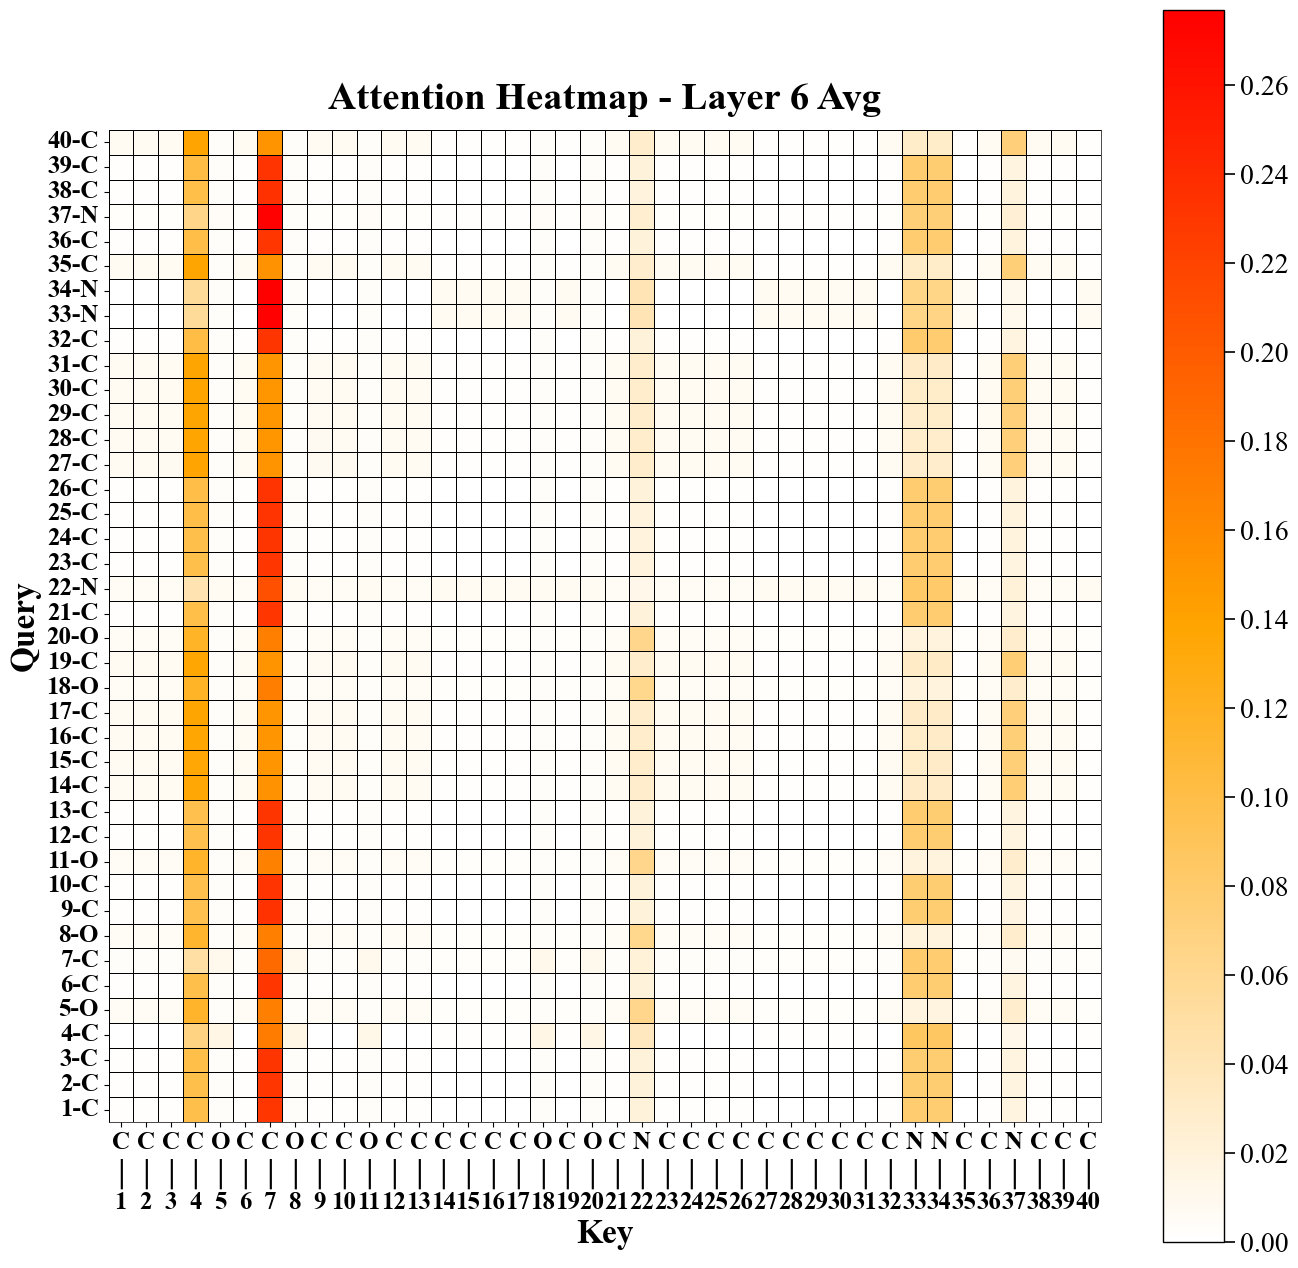

In [47]:
smiles = single_row['Smiles'].tolist()[0]
mol = Chem.MolFromSmiles(smiles)
atom_symbols = [atom.GetSymbol() for atom in mol.GetAtoms()]
new_labels = [f"{i+1}-{sym}" for i, sym in enumerate(atom_symbols)]
layer_5_avg_df.index = new_labels
layer_5_avg_df.columns = new_labels

y_labels = [f"{i+1}-{sym}" for i, sym in enumerate(atom_symbols)]

x_labels = [f"{sym}\n│\n{i+1}" for i, sym in enumerate(atom_symbols)]

plt.figure(figsize=(9,9))

colors = ["white", "orange", "red"]
custom_cmap = LinearSegmentedColormap.from_list("white_orange_red", colors)

vmin_value = 0.0   # 最小值对应白色
vmax_value = 0.2769   # 最大值对应红色 0.4

ax = sns.heatmap(layer_5_avg_df, 
                 xticklabels=x_labels, 
                 yticklabels=y_labels, 
                 cmap=custom_cmap, # 图例的颜色
                 vmin=vmin_value, # 图例的最小值
                 vmax=vmax_value, # 图例的最大值
                 linewidths=0.5, # 方格边框宽度
                 linecolor='black', # 方格边框颜色
                 square=True # 强制方格为正方形
                ) 

plt.xlabel("Key", fontsize=24, fontweight='bold')
plt.ylabel("Query", fontsize=24, fontweight='bold')

plt.title("Attention Heatmap - Layer 6 Avg", fontsize=28, pad=15, fontweight='bold')
plt.xticks(rotation=0,fontsize=14, weight='bold')
plt.yticks(rotation=0,fontsize=14, weight='bold')

# 翻转 y 轴，让原点在左下角
ax.invert_yaxis()

# 添加整个图的边框
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(0.5)      # 边框宽度
    spine.set_color('black')    # 边框颜色

# ========= 添加图例的边框 =========
cbar = ax.collections[0].colorbar
cbar.outline.set_visible(True)       # 使边框可见
cbar.outline.set_linewidth(1.0)      # 边框宽度
cbar.outline.set_edgecolor('black')  # 边框颜色

# ========= 设置图例主刻度 =========
major_ticks = [0.00, 0.02, 0.04, 0.06, 0.08,0.10,0.12,0.14,0.16,0.18,0.20,0.22,0.24,0.26]
#major_ticks = [0.00,0.01, 0.02, 0.03, 0.04]
cbar.set_ticks(major_ticks)
cbar.set_ticklabels([f"{t:.2f}" for t in major_ticks])
# 设置主刻度线样式
cbar.ax.tick_params(
    which='major',
    length=8,      # 主刻度长度
    width=1.2,     # 主刻度线宽度
    direction='out',
    color='black',
    labelsize=20 # 主刻度线值的大小
)

plt.savefig(r"E:\Projects\Mycobacterium tuberculosis\Heatmap of the candidate molecule\TCM2769_layer_5_avg-16.pdf", format='pdf', bbox_inches='tight')

plt.show()